# 13 · Object detection in micrographs (optional)

*Find *where* defects are, not just whether they exist.*

> ⏱ **Runtime:** ~5 s (illustration mode) on a laptop CPU (no GPU) · 🎓 **Level:** beginner · optional · 📊 **Data:** synthetic micrograph

### 🎯 What you'll learn
1. the difference between **classification** (what) and **detection** (what *and where*),
2. what a detector returns per object: a **box**, a **class**, and a **confidence**,
3. how to run **YOLO** if `ultralytics` is installed (and why the notebook still runs if not),
4. the recipe to train a detector on **your own** micrographs.

### 🧭 What you need to know first
- Notebooks 04/10 (CNNs) help, but are not required.
- This notebook is **optional and heavy** — it is not part of the core CPU path or CI.

> ⚠️ **Optional / heavy.** The real detector needs `pip install ultralytics` and, for training, a
> labelled image set. This notebook is written to run **gracefully even when those are absent**
> (it falls back to an illustration), so it never blocks the rest of the tutorial and is **excluded
> from the automated CI**.

### Step 0: set-up

Run this setup cell before anything else (**Shift + Enter** runs a cell).

> 🟢 **On Google Colab** this also sets up the repo and the extra packages (about a minute, first run only). On your own machine it is immediate after installing the requirements.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py`. That confirms the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


> 🧠 **object detection** — locating and labelling every object in an image — drawing a box around each and naming it — unlike classification, which gives one label for the whole image.

> 🧠 **YOLO** — 'You Only Look Once', a fast, popular family of detectors. The `ultralytics` package provides ready-to-use pretrained models.

> ✅ **What appears:** either 'ultralytics not installed — running in illustration mode' (the normal case here) or nothing, if you have it installed.

In [2]:
# Optional dependency — the notebook degrades gracefully if it is missing.
try:
    from ultralytics import YOLO
    HAVE_YOLO = True
except Exception as e:
    HAVE_YOLO = False
    print("ultralytics not installed — running in illustration mode.")
    print("  enable the real detector with:  pip install ultralytics")

ultralytics not installed — running in illustration mode.
  enable the real detector with:  pip install ultralytics


## 1 · What a detector returns

For each object, a detector outputs a bounding **box** (where), a **class** (what), and a
**confidence** (how sure). Here is a synthetic micrograph with a few bright 'defects' and the kind
of boxes a detector would draw.

> 🧠 **bounding box + confidence** — the rectangle around a detected object, plus a 0–1 score for how confident the model is. You keep detections above a chosen confidence.

> ✅ **What appears:** a grey synthetic micrograph with four red boxes, each labelled 'defect' with a confidence number.

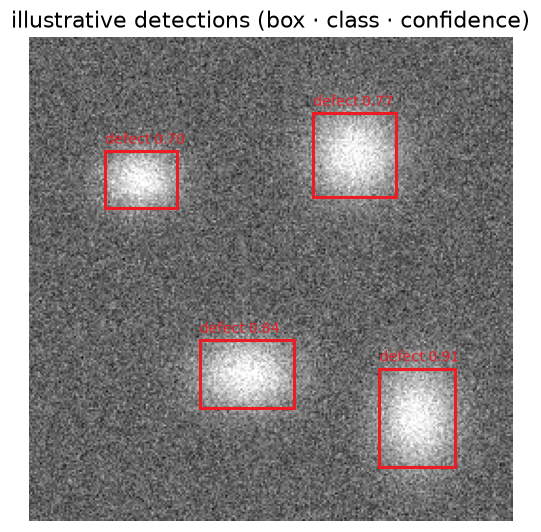

In [3]:
from matplotlib.patches import Rectangle
rng = np.random.default_rng(1)
img = rng.normal(0.5, 0.08, (256, 256))              # noisy grey background
boxes = [(40, 60, 38, 30), (150, 40, 44, 44), (90, 160, 50, 36), (185, 175, 40, 52)]
for x, y, w, h in boxes:                              # paint a brighter blob inside each box
    yy, xx = np.ogrid[:256, :256]
    img += 0.5 * np.exp(-(((xx - (x + w / 2)) / (w / 2)) ** 2 + ((yy - (y + h / 2)) / (h / 2)) ** 2))
img = np.clip(img, 0, 1)

fig, ax = plt.subplots(figsize=(5, 5)); ax.imshow(img, cmap="gray")
for i, (x, y, w, h) in enumerate(boxes):
    ax.add_patch(Rectangle((x, y), w, h, fill=False, ec="#ED1C24", lw=2))
    ax.text(x, y - 4, f"defect {0.7 + 0.07 * i:.2f}", color="#ED1C24", fontsize=9)
ax.set_title("illustrative detections (box · class · confidence)"); ax.axis("off"); fig.tight_layout()

*🖼 **Figure.** These boxes are hand-drawn to show the *format* of a detection. A trained YOLO model produces exactly this kind of output automatically.*

## 2 · Running a real YOLO model

If `ultralytics` is installed (and a model can be fetched), this runs actual inference; otherwise it
is skipped cleanly.

> ✅ **What appears:** in illustration mode, 'Skipped — install ultralytics to run the real detector.' With ultralytics installed and online, a YOLOv8 annotated image instead.

In [4]:
if HAVE_YOLO:
    try:
        import tempfile
        d = tempfile.mkdtemp(prefix="yolo_demo_")     # cross-platform temp dir (Windows-safe)
        sample = os.path.join(d, "sample.png")
        plt.imsave(sample, img, cmap="gray")
        model = YOLO("yolov8n.pt")                     # tiny pretrained model (downloaded once)
        res = model(sample, verbose=False)
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(res[0].plot()[..., ::-1]); ax.axis("off"); ax.set_title("YOLOv8 output")
        print("detections:", len(res[0].boxes))
    except Exception as e:
        print("YOLO available but inference skipped (offline model fetch?):", type(e).__name__)
else:
    print("Skipped — install ultralytics to run the real detector.")

Skipped — install ultralytics to run the real detector.


## 3 · Training on your own micrographs

1. **Label** a few hundred images (boxes + classes) with a tool like **Roboflow**, **labelImg**, or
   **CVAT**; export in **YOLO format**.
2. Point a `data.yaml` at your `train/` and `val/` folders and class names.
3. **Fine-tune** from a small pretrained model:

```python
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
model.train(data="data.yaml", epochs=100, imgsz=640)
```

4. **Validate** on held-out images and **report precision/recall per class** — the same honesty as
   everywhere else in this tutorial.

### ✅ Self-check
A quick sanity check that the illustration ran — the optional-dependency flag resolved and the demo drew its example boxes. If you edit the notebook and something breaks, the cell below stops with an `AssertionError` — a helpful early warning, not a bug.

In [5]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert isinstance(HAVE_YOLO, bool), "the optional-dependency check should have run"
assert len(boxes) == 4, "the illustration should draw four example boxes"
print("self-check passed ✓ — detection demo ready")

self-check passed ✓ — detection demo ready


## ✅ Recap
- **Detection = classification + localisation.** YOLO is the practical default tool.
- Use it to locate defects, precipitates, or indents in micrographs.
- This notebook is **optional**; the core nanoindentation ML story lives in notebooks 00–06.

## 🔧 Try it yourself
The best way to learn is to change one thing at a time:
1. Move or resize the boxes in Section 1 — the illustration updates. What confidence would you trust as a real detection threshold?
2. If you have GPU access elsewhere, install `ultralytics` and re-run Section 2 to see real YOLO output.
3. Sketch (in a markdown cell) what classes you would label for *your* micrographs (e.g. crack, pore, precipitate).

## 🩹 Common errors & fixes
- **'ultralytics not installed'** → expected here; the notebook is designed to run without it.
- **Real YOLO cell prints an error about model fetch** → it needs internet to download `yolov8n.pt` once.
- **Don't add this to CI** → it is heavy and optional by design.

---
**Next:** you've finished the classics! See **`00_start_here`** for the full map, or the new on-ramps **`01a`**, **`02a`**, **`03a`**.